### Content Consumption Behavior Analysis

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
plt.style.use('seaborn')
%matplotlib inline

C:\Users\rohan\AppData\Local\Temp\ipykernel_17468\3081944378.py:8: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


In [ ]:
# Load data
lio_consumption = pd.read_csv('LioCinema CSV files/content_consumption.csv')
jotstar_consumption = pd.read_csv('Jotstar CSV files/content_consumption.csv')
lio_subs = pd.read_csv('LioCinema CSV files/subscribers.csv')
jotstar_subs = pd.read_csv('Jotstar CSV files/subscribers.csv')

In [11]:
lio_subs.head()

,user_id,age_group,city_tier,subscription_date,subscription_plan,last_active_date,plan_change_date,new_subscription_plan
0,UIDLC00000bea68a,25-34,Tier 3,2024-10-24,Free,NaN,NaN,NaN
1,UIDLC00009202848,18-24,Tier 1,2024-09-18,Basic,NaN,NaN,NaN
2,UIDLC0001086afc3,35-44,Tier 2,2024-03-23,Premium,NaN,2024-04-23,Free
3,UIDLC000186abd93,18-24,Tier 3,2024-09-07,Free,2024-10-23,NaN,NaN
4,UIDLC0002189b09f,18-24,Tier 2,2024-10-07,Premium,NaN,2024-11-07,Free


In [15]:
lio_consumption.head()

,user_id,device_type,total_watch_time_mins,platform
0,UIDLC459c98ee486,Mobile,502,LioCinema
1,UIDLCe4b2fd90790,Mobile,2098,LioCinema
2,UIDLCbc8f0a05367,Mobile,557,LioCinema
3,UIDLC9fc67130445,Mobile,1720,LioCinema
4,UIDLC7026c3e0374,Mobile,908,LioCinema


In [28]:
jotstar_consumption['device_type'].unique()

array(['Mobile'], dtype=object)

In [7]:
lio_consumption.isnull().sum()

user_id                  0
device_type              0
total_watch_time_mins    0
dtype: int64

In [12]:
# Add platform identifiers and merge
lio_consumption['platform'] = 'LioCinema'
jotstar_consumption['platform'] = 'Jotstar'
combined_consumption = pd.concat([lio_consumption, jotstar_consumption])


lio_subs['platform'] = 'LioCinema'
jotstar_subs['platform'] = 'Jotstar'
# Merge with subscriber data
combined_data = pd.merge(
    pd.concat([lio_subs, jotstar_subs]),
    combined_consumption,
    on=['user_id', 'platform'],
    how='left'
)



In [14]:
# =============================================
# 1. Compare Watch Time Across Platforms/Demographics
# =============================================

In [ ]:
# Summary statistics
print("Average Watch Time (mins) by Platform:")
print(combined_data.groupby('platform')['total_watch_time_mins'].describe())

Average Watch Time (mins) by Platform:
           count         mean          std     min     25%     50%       75%  \
platform                                                                       
Jotstar     25.0  9946.640000  8470.476181  1032.0  2739.0  6676.0  14718.00   
LioCinema    6.0  3700.333333  3901.121514   175.0   634.0  2873.0   5510.25   

               max  
platform            
Jotstar    27102.0  
LioCinema  10004.0  


Text(0.5, 0, '')

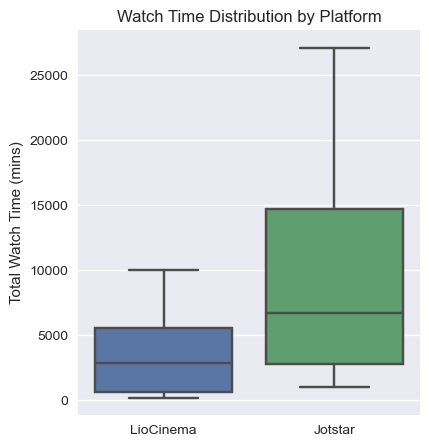

In [18]:
# Visualization
plt.figure(figsize=(15, 5))

# Platform comparison
plt.subplot(1, 3, 1)
sns.boxplot(data=combined_data, x='platform', y='total_watch_time_mins')
plt.title('Watch Time Distribution by Platform')
plt.ylabel('Total Watch Time (mins)')
plt.xlabel('')

#### Interpretation


- **LioCinema**

- Median watch time is lower (around 2,500 mins).
- IQR is tight — most users watched between ~500 to ~5,000 mins.
- Maximum watch time (whisker top) is around 10,000 mins.
- Distribution is relatively compact and consistent.

--- 
- **Jotstar**

- Median watch time is higher (around 6,500–7,000 mins).
- IQR is wider — big spread in user watch times (from ~2,000 to ~15,000 mins).
- Max watch time is very high (~27,000 mins), suggesting some users are watching a lot more than others.
- More variability in watch behavior on this platform.

---
- **What This Tells You:**
- LioCinema has a more consistent user base with similar watch times.
- Jotstar has higher engagement overall, but also more variability — some power users are watching a lot more.

Text(0.5, 0, 'Age Group')

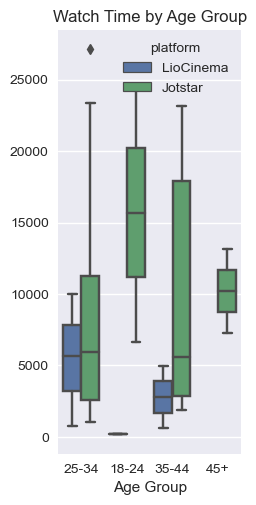

In [20]:
# Age group comparison
plt.subplot(1, 3, 2)
sns.boxplot(data=combined_data, x='age_group', y='total_watch_time_mins', hue='platform')
plt.title('Watch Time by Age Group')
plt.ylabel('')
plt.xlabel('Age Group')

- Interpretation

- 25–34

Jotstar: Higher and more spread out watch time.

LioCinema: Lower, more consistent watch time.

- 18–24

Jotstar: Very high variability; some users watch a lot (up to 25,000+ mins).

LioCinema: Mostly low watch time, very small IQR.

- 35–44

Both platforms have moderate watch time, but:

Jotstar has higher max and median.

LioCinema again shows less variability.

- 45+

Only Jotstar has data here.

Watch time is moderate to high and fairly consistent.

---

- Overall Takeaways:

Jotstar dominates in terms of watch time across all age groups.

LioCinema users are generally more consistent but watch less.

18–24 and 25–34 are the most variable groups, especially on Jotstar.

Jotstar may be more appealing to younger and older viewers alike.

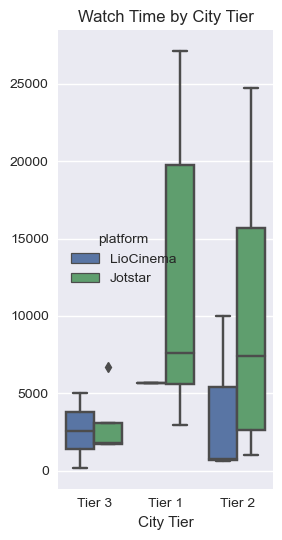

In [22]:
# City tier comparison
plt.subplot(1, 3, 3)
sns.boxplot(data=combined_data, x='city_tier', y='total_watch_time_mins', hue='platform')
plt.title('Watch Time by City Tier')
plt.ylabel('')
plt.xlabel('City Tier')

plt.tight_layout()
plt.show()

Tier 3 Cities

Both platforms have low to moderate watch time.

LioCinema has a slightly wider spread but lower max watch time.

A few outliers exist (for LioCinema).

---

Tier 2 Cities

Jotstar again shows higher engagement and variability.

LioCinema has moderate watch time, with a tighter spread and lower median.

---

Tier 1 Cities

Jotstar has very high and widely spread watch time — median and max are much higher than LioCinema.

LioCinema has much lower, tightly packed watch times — less engagement.

---

Overall Takeaways:

Jotstar leads in all city tiers, especially in Tier 1 and Tier 2 cities.

LioCinema’s watch time is more consistent, but lower overall.

Tier 1 cities have the highest watch time on Jotstar — possibly more access to fast internet, premium content, or targeted users.

Tier 3 engagement is low for both, indicating potential growth opportunity.